<a href="https://colab.research.google.com/github/Pranav-Trivedi20/MNIST-and-Fashion-MNIST-dataset-optimization/blob/main/Iris_and_Wine_dataset_Model_Optimization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import Iris dataset
from sklearn.datasets import load_iris

# Train-test split
from sklearn.model_selection import train_test_split

# Training algorithm
from sklearn.linear_model import LogisticRegression

# Load dataset
iris = load_iris()

X = iris.data      # Features
y = iris.target    # Labels

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [2]:
# Feature names
print("Features:")
print(iris.feature_names)

# Target classes
print("\nClasses:")
print(iris.target_names)

# Dataset shape
print("\nDataset Shape:")
print("X:", X.shape)
print("y:", y.shape)

Features:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes:
['setosa' 'versicolor' 'virginica']

Dataset Shape:
X: (150, 4)
y: (150,)


In [3]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


In [4]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [5]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#selecting 2 best features

In [6]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 2 features
selector = SelectKBest(score_func=f_classif, k=2)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [7]:
selected_features = [
    iris.feature_names[i]
    for i in range(len(iris.feature_names))
    if selector.get_support()[i]
]

print("Selected Features:")
print(selected_features)

Selected Features:
['petal length (cm)', 'petal width (cm)']


In [8]:
for name, score in zip(iris.feature_names, selector.scores_):
    print(f"{name}: {score:.2f}")

sepal length (cm): 84.81
sepal width (cm): 41.29
petal length (cm): 925.56
petal width (cm): 680.78


#Train Model Using Selected Features Only

In [9]:
from sklearn.linear_model import LogisticRegression

model_selected = LogisticRegression(max_iter=1000)

model_selected.fit(X_train_selected, y_train)

LogisticRegression(max_iter=1000)

#Evaluate Again

In [10]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_selected = model_selected.predict(X_test_selected)

print("Accuracy :", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_selected, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_selected, average='weighted'))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


##Now took wine dataset prune it and make similar to iris dataset(178,4). and again train the same model

In [11]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

print("Original Shape:", X.shape)   # (178, 13)

# Keep only first 4 features
X = X[:, :4]

print("Pruned Shape:", X.shape)     # (178, 4)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Train model
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Wine model trained successfully!")

Original Shape: (178, 13)
Pruned Shape: (178, 4)
Wine model trained successfully!


In [12]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.8611111111111112
Precision: 0.8735042735042735
Recall   : 0.8611111111111112
F1 Score : 0.8641975308641974


In [13]:
print(confusion_matrix(y_test, y_pred))

[[12  0  2]
 [ 1 12  1]
 [ 0  1  7]]


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       0.92      0.86      0.89        14
     class_1       0.92      0.86      0.89        14
     class_2       0.70      0.88      0.78         8

    accuracy                           0.86        36
   macro avg       0.85      0.86      0.85        36
weighted avg       0.87      0.86      0.86        36



#Now perform feature selection

In [15]:
from sklearn.feature_selection import SelectKBest, f_classif

# Select top 2 features
selector = SelectKBest(score_func=f_classif, k=2)

X_train_selected = selector.fit_transform(X_train, y_train)
X_test_selected = selector.transform(X_test)

In [16]:
selected_features = [
    wine.feature_names[:4][i]
    for i in range(4)
    if selector.get_support()[i]
]

print("Selected Features:")
print(selected_features)

Selected Features:
['alcohol', 'alcalinity_of_ash']


In [17]:
for name, score in zip(wine.feature_names[:4], selector.scores_):#feature score
    print(f"{name}: {score:.2f}")

alcohol: 89.65
malic_acid: 28.70
ash: 9.90
alcalinity_of_ash: 30.47


In [18]:
from sklearn.linear_model import LogisticRegression  #train using selected 2 features
model_selected = LogisticRegression(max_iter=1000)

model_selected.fit(X_train_selected, y_train)

LogisticRegression(max_iter=1000)

In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_selected = model_selected.predict(X_test_selected)

print("Accuracy :", accuracy_score(y_test, y_pred_selected))
print("Precision:", precision_score(y_test, y_pred_selected, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_selected, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_selected, average='weighted'))

Accuracy : 0.8333333333333334
Precision: 0.8435897435897436
Recall   : 0.8333333333333334
F1 Score : 0.8353909465020575


As all the scores decresed

##CONCLUSION: Selecting 2 best features reduces performance of the model.
This shows that more features improves the model performance.

#Now we are using all 13 features of wine dataset.

In [20]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load Wine dataset
wine = load_wine()

# Use ALL 13 features
X = wine.data
y = wine.target

print("Dataset Shape:", X.shape)   # (178, 13)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LogisticRegression(max_iter=5000)

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

Dataset Shape: (178, 13)
Model trained successfully!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
#scaling as dataset cant converge with original values
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

model.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(max_iter=5000))])

In [22]:
print("Features Used:")
for feature in wine.feature_names:
    print(feature)

Features Used:
alcohol
malic_acid
ash
alcalinity_of_ash
magnesium
total_phenols
flavanoids
nonflavanoid_phenols
proanthocyanins
color_intensity
hue
od280/od315_of_diluted_wines
proline


In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Predictions
y_pred = model.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0


# Using all features gives optimum results.
(Conc: More features better results.)

In [24]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[14  0  0]
 [ 0 14  0]
 [ 0  0  8]]


In [25]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=wine.target_names
))

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [26]:
import time

start = time.time()

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

training_time = time.time() - start

print("Training Time:", training_time, "seconds")

Training Time: 5.095340013504028 seconds


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)




LogisticRegression(max_iter=5000)

Feature scaling improves optimization by helping gradient-based algorithms converge faster and more reliably, reducing training time and eliminating convergence issues.

#Now finding redundant features and eliminating them

In [28]:
#Method 1: Feature Importance using SelectKBest
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X, y)

feature_scores = pd.DataFrame({
    'Feature': wine.feature_names,
    'Score': selector.scores_
})

print(feature_scores.sort_values(
    by='Score',
    ascending=False
))

                         Feature       Score
6                     flavanoids  233.925873
12                       proline  207.920374
11  od280/od315_of_diluted_wines  189.972321
0                        alcohol  135.077624
9                color_intensity  120.664018
10                           hue  101.316795
5                  total_phenols   93.733010
1                     malic_acid   36.943425
3              alcalinity_of_ash   35.771637
8                proanthocyanins   30.271383
7           nonflavanoid_phenols   27.575417
2                            ash   13.312901
4                      magnesium   12.429584


In [29]:
#Correlation Matrix:Highly correlated features often contain similar information.
import pandas as pd

df = pd.DataFrame(X, columns=wine.feature_names)

corr_matrix = df.corr()

print(corr_matrix.round(2))

                              alcohol  malic_acid   ash  alcalinity_of_ash  \
alcohol                          1.00        0.09  0.21              -0.31   
malic_acid                       0.09        1.00  0.16               0.29   
ash                              0.21        0.16  1.00               0.44   
alcalinity_of_ash               -0.31        0.29  0.44               1.00   
magnesium                        0.27       -0.05  0.29              -0.08   
total_phenols                    0.29       -0.34  0.13              -0.32   
flavanoids                       0.24       -0.41  0.12              -0.35   
nonflavanoid_phenols            -0.16        0.29  0.19               0.36   
proanthocyanins                  0.14       -0.22  0.01              -0.20   
color_intensity                  0.55        0.25  0.26               0.02   
hue                             -0.07       -0.56 -0.07              -0.27   
od280/od315_of_diluted_wines     0.07       -0.37  0.00         

Strongly Correlated Features:
total_phenols ↔ flavanoids

flavanoids ↔ od280/od315_of_diluted_wines

In [30]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Load dataset
wine = load_wine()

# Create DataFrame
import pandas as pd
df = pd.DataFrame(wine.data, columns=wine.feature_names)

# Remove 2 highly correlated features
X = df.drop(
    columns=[
        "flavanoids",
        "od280/od315_of_diluted_wines"
    ]
)

y = wine.target

print("New Shape:", X.shape)   # Should be (178, 11)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model_reduced = LogisticRegression(max_iter=5000)

model_reduced.fit(X_train_scaled, y_train)

print("Model trained successfully!")

New Shape: (178, 11)
Model trained successfully!


In [31]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

y_pred = model_reduced.predict(X_test_scaled)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))

Accuracy : 0.9722222222222222
Precision: 0.9753086419753088
Recall   : 0.9722222222222222
F1 Score : 0.9725248123940935


with all 13 features:

Accuracy : 1.0

Precision: 1.0

Recall   : 1.0

F1 Score : 1.0

with 11 features:

Accuracy : 0.9722222222222222

Precision: 0.9753086419753088

Recall   : 0.9722222222222222

F1 Score : 0.9725248123940935
#(Conc: Althrough model score decreases but these are the most important 11 features.)
#eliminating any other instead of these 2 will reduce more score.

In [32]:
#Apply RFE to select top 5 features
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# Base model
base_model = LogisticRegression(max_iter=5000)

# Select top 5 features
rfe = RFE(
    estimator=base_model,
    n_features_to_select=5
)

rfe.fit(X_train_scaled, y_train)

# Print selected features
selected_features = [
    feature
    for feature, keep in zip(
        wine.feature_names,
        rfe.support_
    )
    if keep
]

print("Top 5 Features:")
print(selected_features)

Top 5 Features:
['alcohol', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue']


In [33]:
#Create Dataset with Only Selected Features
X_train_rfe = rfe.transform(X_train_scaled)
X_test_rfe = rfe.transform(X_test_scaled)

print("Original Shape:", X_train_scaled.shape)
print("RFE Shape:", X_train_rfe.shape)

Original Shape: (142, 11)
RFE Shape: (142, 5)


In [34]:
#Train Model and Measure Training Time
import time
from sklearn.linear_model import LogisticRegression

start = time.time()

model_rfe = LogisticRegression(max_iter=5000)

model_rfe.fit(X_train_rfe, y_train)

training_time_rfe = time.time() - start

print("Training Time:", training_time_rfe)

Training Time: 0.09315347671508789


In [35]:
#Evaluate performance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_pred_rfe = model_rfe.predict(X_test_rfe)

print("Accuracy :", accuracy_score(y_test, y_pred_rfe))
print("Precision:", precision_score(
    y_test, y_pred_rfe,
    average='weighted'
))
print("Recall   :", recall_score(
    y_test, y_pred_rfe,
    average='weighted'
))
print("F1 Score :", f1_score(
    y_test, y_pred_rfe,
    average='weighted'
))

Accuracy : 0.9722222222222222
Precision: 0.9753086419753088
Recall   : 0.9722222222222222
F1 Score : 0.9725248123940935


accuracy with 11 features and accuracy with 5 features identical.
#Same accuracy, less time means  Excellent feature selection

#Hyperparameter Optimization:


In [36]:
#Trying different values of c
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time

C_values = [0.01, 0.1, 1, 10, 100]

for C in C_values:

    start = time.time()

    model = LogisticRegression(
        C=C,
        max_iter=5000
    )

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print(
        f"C={C:6} | "
        f"Accuracy={accuracy:.4f} | "
        f"F1={f1:.4f} | "
        f"Time={training_time:.4f}s"
    )

C=  0.01 | Accuracy=1.0000 | F1=1.0000 | Time=0.0568s
C=   0.1 | Accuracy=1.0000 | F1=1.0000 | Time=0.0799s
C=     1 | Accuracy=0.9722 | F1=0.9725 | Time=0.0770s
C=    10 | Accuracy=0.9722 | F1=0.9725 | Time=0.0524s
C=   100 | Accuracy=0.9722 | F1=0.9725 | Time=0.0315s


In [37]:
#Using Cross Validation
from sklearn.model_selection import cross_val_score

for C in [0.01, 0.1, 1, 10, 100]:

    model = LogisticRegression(
        C=C,
        max_iter=5000
    )

    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5
    )

    print(
        f"C={C} | "
        f"Mean Accuracy={scores.mean():.4f}"
    )

C=0.01 | Mean Accuracy=0.9645
C=0.1 | Mean Accuracy=0.9648
C=1 | Mean Accuracy=0.9719
C=10 | Mean Accuracy=0.9719
C=100 | Mean Accuracy=0.9648


In [40]:
#Finding best parameter
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(X_train_scaled, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score :", grid.best_score_)

Best Parameters: {'C': 1}
Best CV Score : 0.97192118226601


##Small C underfitting

##Large C overfitting

## We need to find a balance.

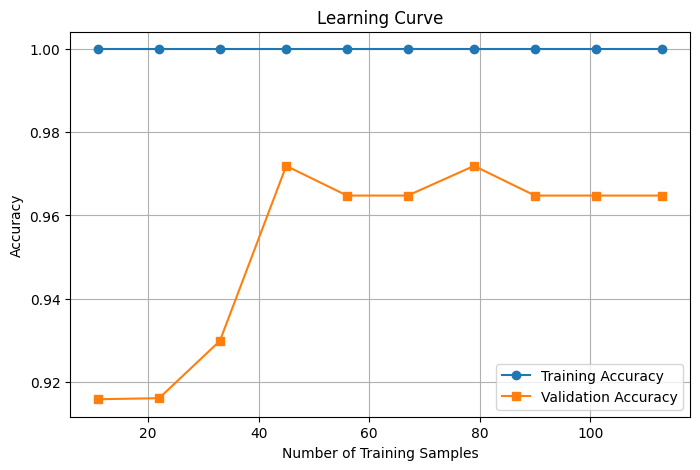

In [43]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores.mean(axis=1),
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    train_sizes,
    test_scores.mean(axis=1),
    marker='s',
    label='Validation Accuracy'
)

plt.title("Learning Curve")
plt.xlabel("Number of Training Samples")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend(loc="best")

plt.show()

##Conc: This graph converges at 45 to 50% of traing examples suggests that training data size and the dataset size both can be reduced.
(reducing training time )

#Now Comaparing Different Algorithms

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, f1_score
import time

In [45]:
#Create Model
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

In [46]:
#Comparing
for name, model in models.items():

    start = time.time()

    model.fit(X_train_scaled, y_train)

    training_time = time.time() - start

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    print(f"\n{name}")
    print("Accuracy :", round(accuracy, 4))
    print("F1 Score :", round(f1, 4))
    print("Time     :", round(training_time, 4), "seconds")


Logistic Regression
Accuracy : 0.9722
F1 Score : 0.9725
Time     : 0.0544 seconds

KNN
Accuracy : 0.9444
F1 Score : 0.9436
Time     : 0.0077 seconds

Decision Tree
Accuracy : 0.9167
F1 Score : 0.9159
Time     : 0.0077 seconds

Random Forest
Accuracy : 1.0
F1 Score : 1.0
Time     : 0.3339 seconds

SVM
Accuracy : 1.0
F1 Score : 1.0
Time     : 0.0046 seconds


##SVM is the best one in this case : Most accurate, least Time.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)